,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,12/26/2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,8/5/2023 0:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,3/11/2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,10/27/2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,12/22/2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


          CustomerID       Quantity          Price  DiscountApplied(%)  \
count  100000.000000  100000.000000  100000.000000       100000.000000   
mean   500463.982180       5.009290      55.067344           10.020155   
std    288460.917524       2.579808      25.971567            5.779534   
min        14.000000       1.000000      10.000430            0.000046   
25%    250693.750000       3.000000      32.549474            5.001013   
50%    499679.000000       5.000000      55.116789           10.030353   
75%    751104.750000       7.000000      77.456763           15.018367   
max    999997.000000       9.000000      99.999284           19.999585   

         TotalAmount  
count  100000.000000  
mean      248.334955  
std       184.554792  
min         8.274825  
25%        95.163418  
50%       200.368393  
75%       362.009980  
max       896.141242  
ProductCategory
Books          6.257837e+06
Clothing       6.205502e+06
Electronics    6.196735e+06
Home Decor     6.173421e+0

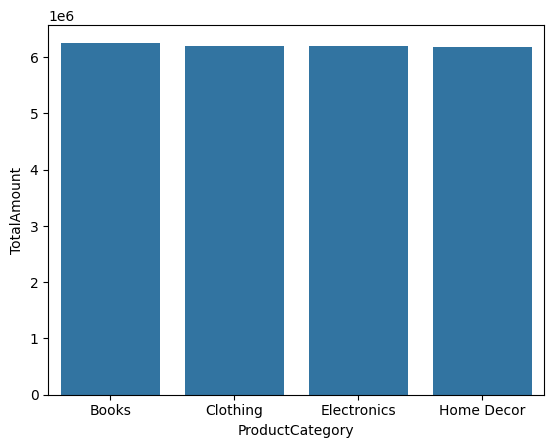

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Rtdf = pd.read_csv('/content/Retail_Transaction_Dataset.csv')
Rtdf

#Carga de datos e información principal

Stads = Rtdf.describe()
Rtdf.head(5)
Rtdf.shape
Rtdf.info



Rtdf.nlargest
display(Rtdf.head())
Rtdf.dtypes
print(Stads)

totalventas = Rtdf.groupby('ProductCategory')['TotalAmount'].sum()
print(totalventas)

totalventas2 = Rtdf.groupby('PaymentMethod')['TotalAmount'].sum()
print(totalventas2)

# Sumar ventas por categoría antes de graficar
resumen = Rtdf.groupby('ProductCategory')['TotalAmount'].sum().reset_index()
sns.barplot(data=resumen, x='ProductCategory', y='TotalAmount')

In [28]:
#Exploración de datos a través de su linea de tiempo

Rtdf['TransactionDate']=pd.to_datetime(Rtdf['TransactionDate'], dayfirst=True) #transformamos primero a formato de dataelike value
Rtdf['fecha']=Rtdf['TransactionDate'].dt.strftime('%d-%m-%Y') # damos formato de fecha latinoamericana
Rtdf['año']=Rtdf['TransactionDate'].dt.year
Rtdf['trim']=Rtdf['TransactionDate'].dt.quarter
Rtdf['mes']=Rtdf['TransactionDate'].dt.month
Rtdf['mesNombre']=Rtdf['TransactionDate'].dt.month_name()

print(Rtdf[['año','trim','mes','mesNombre']])
Rtdf[['año','trim','mes','mesNombre']].describe()


        año  trim  mes mesNombre
0      2023     4   12  December
1      2023     3    8    August
2      2024     1    3     March
3      2023     4   10   October
4      2023     4   12  December
...     ...   ...  ...       ...
99995  2023     3    7      July
99996  2023     2    5       May
99997  2023     3    8    August
99998  2024     1    2  February
99999  2024     1    2  February

[100000 rows x 4 columns]


,año,trim,mes
count,100000.000000,100000.00000,100000.000000
mean,2023.327330,2.50392,6.511440
std,0.469241,1.11957,3.456482
min,2023.000000,1.00000,1.000000
25%,2023.000000,1.00000,3.000000
50%,2023.000000,3.00000,7.000000
75%,2024.000000,4.00000,10.000000
max,2024.000000,4.00000,12.000000


0        2125651.1
1        2109352.6
2        2108248.0
3        2049450.7
4        2125651.1
           ...    
99995    2132550.5
99996    2099576.1
99997    2109352.6
99998    1973154.1
99999    1973154.1
Name: Recaudacion, Length: 100000, dtype: float64
   CustomerID ProductID  Quantity      Price     TransactionDate  \
0      109318         C         7  80.079844 2023-12-26 12:32:00   
1      993229         C         4  75.195229 2023-08-05 00:00:00   
2      579675         A         8  31.528816 2024-03-11 18:51:00   
3      799826         D         5  98.880218 2023-10-27 22:00:00   
4      121413         A         7  93.188512 2023-12-22 11:38:00   

  PaymentMethod                                      StoreLocation  \
0          Cash            176 Andrew Cliffs\nBaileyfort, HI 93354   
1          Cash  11635 William Well Suite 809\nEast Kara, MT 19483   
2          Cash  910 Mendez Ville Suite 909\nPort Lauraland, MO...   
3        PayPal  87522 Sharon Corners Suite 500\nLak

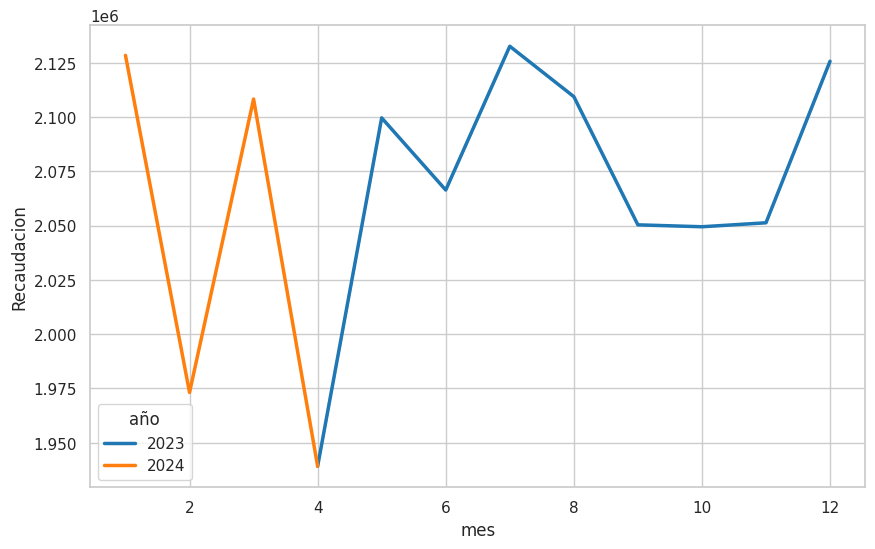

In [55]:

sns.set_theme(style="whitegrid")

DtDf = pd.DataFrame(Rtdf)
#print(DtDf.head())

DtDf['Recaudacion'] = round(DtDf.groupby('mes')['TotalAmount'].transform('sum'),1)
print(DtDf['Recaudacion'])
print(DtDf.head())


plt.figure(figsize=(10,6))
sns.lineplot(data=DtDf, x= 'mes', y='Recaudacion', hue='año',palette="tab10", linewidth=2.5)
plt.show()

Monthly Recaudacion by Year and Payment Method Head:
    año  mes PaymentMethod    Recaudacion
0  2023    4          Cash   14269.386557
1  2023    4   Credit Card   18337.494918
2  2023    4    Debit Card   16224.479814
3  2023    4        PayPal   12009.426565
4  2023    5          Cash  546122.615080


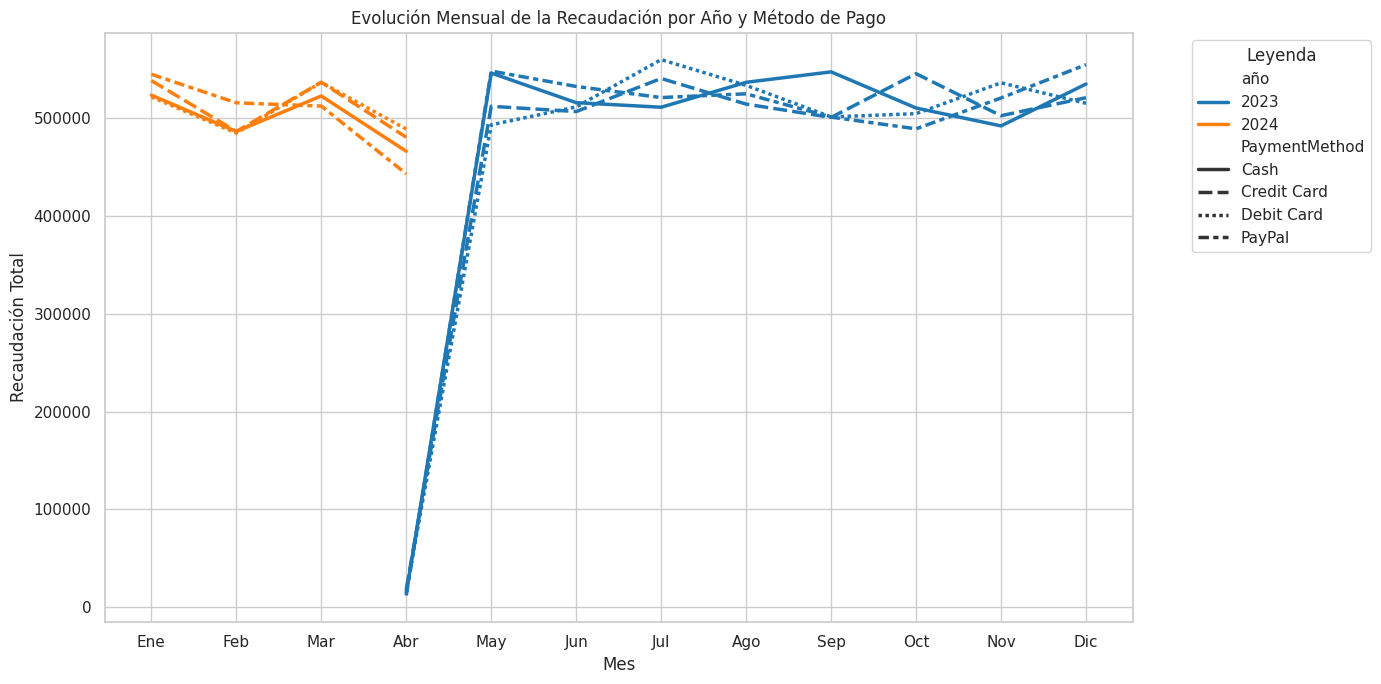

In [58]:

sns.set_theme(style="whitegrid")

# Group by 'año', 'mes', and 'PaymentMethod' to get distinct monthly recaudacion for each year and payment method
monthly_recaudacion_by_payment = Rtdf.groupby(['año', 'mes', 'PaymentMethod'])['TotalAmount'].sum().reset_index()
monthly_recaudacion_by_payment.rename(columns={'TotalAmount': 'Recaudacion'}, inplace=True)

print("Monthly Recaudacion by Year and Payment Method Head:")
print(monthly_recaudacion_by_payment.head())

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=monthly_recaudacion_by_payment,
    x='mes',
    y='Recaudacion',
    hue='año', # Different colors for each year
    style='PaymentMethod', # Different line styles for each payment method
    palette="tab10",
    linewidth=2.5
)

plt.title('Evolución Mensual de la Recaudación por Año y Método de Pago')
plt.xlabel('Mes')
plt.ylabel('Recaudación Total')
plt.xticks(ticks=range(1, 13), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.legend(title='Leyenda', bbox_to_anchor=(1.05, 1), loc='upper left') # Adjust legend position
plt.grid(True)
plt.tight_layout()
plt.show()

Recaudación Mensual por Año, Categoría de Producto y Método de Pago (primeras filas):
    año  mes ProductCategory PaymentMethod  Recaudacion
0  2023    4           Books          Cash  4810.230128
1  2023    4           Books   Credit Card  4273.405189
2  2023    4           Books    Debit Card  5509.656122
3  2023    4           Books        PayPal  3124.213044
4  2023    4        Clothing          Cash  3405.405639


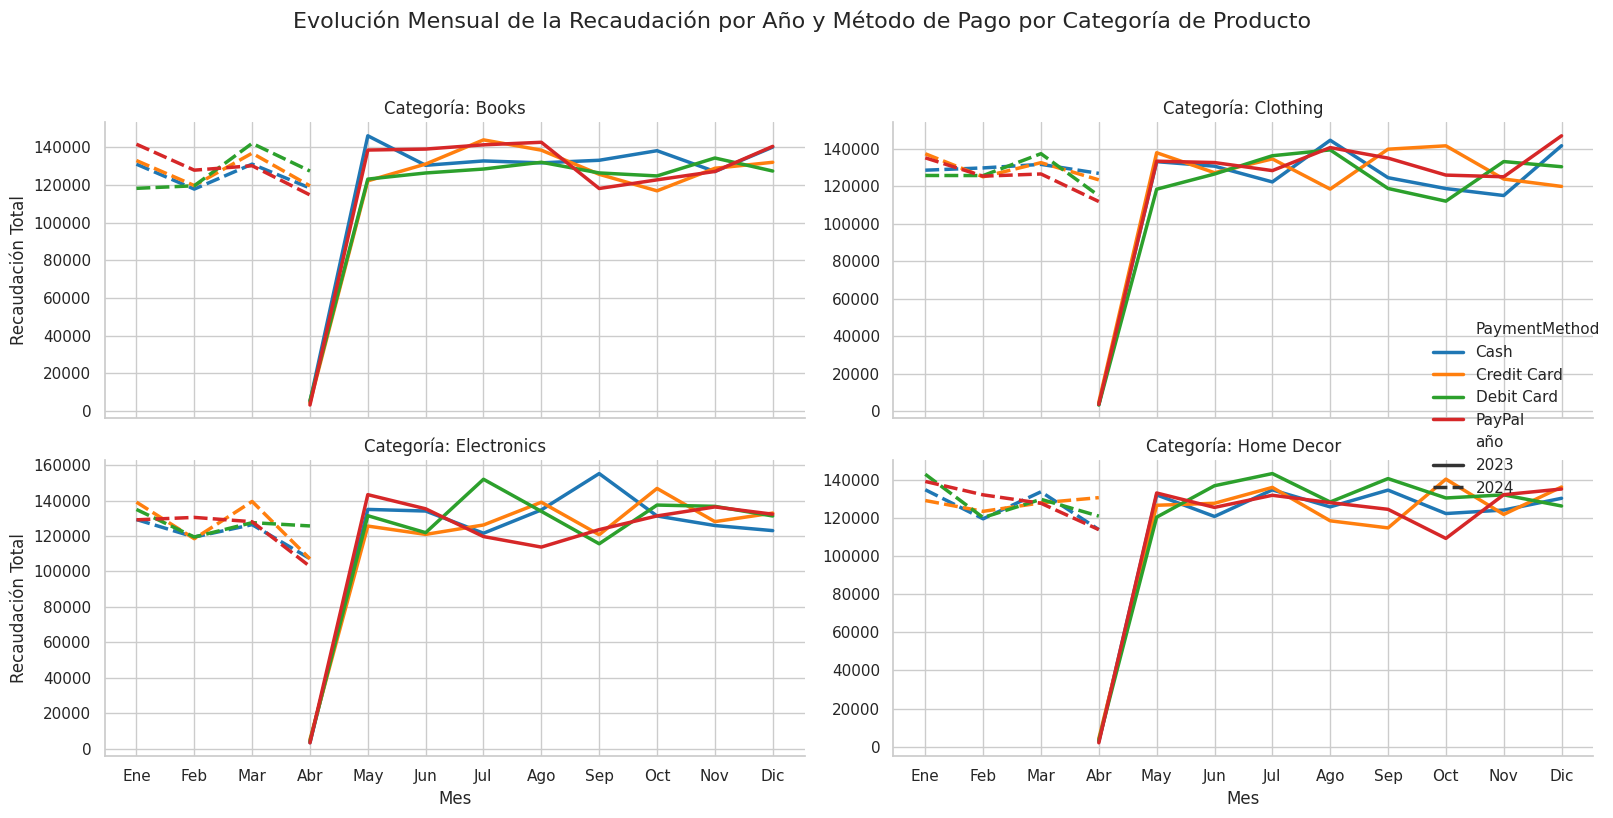

In [64]:
# Establecemos el tema visual de Seaborn para los gráficos, usando un estilo de cuadrícula blanca para una mejor legibilidad.
sns.set_theme(style="whitegrid")

# Agrupamos los datos para calcular la recaudación total.
# Agrupamos por año ('año'), mes ('mes'), categoría de producto ('ProductCategory') y método de pago ('PaymentMethod').
# Luego, sumamos el 'TotalAmount' para cada una de estas combinaciones.
# reset_index() convierte el resultado de la agrupación (que es una Serie) de nuevo en un DataFrame.
revenue_by_category_payment_month = Rtdf.groupby(['año', 'mes', 'ProductCategory', 'PaymentMethod'])['TotalAmount'].sum().reset_index()

# Renombramos la columna 'TotalAmount' a 'Recaudacion' para mayor claridad en el contexto del análisis.
revenue_by_category_payment_month.rename(columns={'TotalAmount': 'Recaudacion'}, inplace=True)

# Imprimimos las primeras filas del DataFrame resultante para verificar la estructura de los datos agregados.
print("Recaudación Mensual por Año, Categoría de Producto y Método de Pago (primeras filas):")
print(revenue_by_category_payment_month.head())

# Creamos una matriz de gráficos de líneas utilizando `seaborn.relplot`.
# `col='ProductCategory'` creará columnas separadas para cada categoría de producto.
# `kind='line'` especifica que queremos gráficos de líneas.
# `x='mes'` y `y='Recaudacion'` definen los ejes del gráfico.
# `hue='año'` diferenciará las líneas por año, usando diferentes colores.
# `style='PaymentMethod'` diferenciará las líneas por método de pago, usando diferentes estilos.
# `height` y `aspect` ajustan el tamaño de cada subgráfico.
# `palette="tab10"` usa una paleta de colores predefinida.
g = sns.relplot(
    data=revenue_by_category_payment_month,
    x='mes',
    y='Recaudacion',
    hue='PaymentMethod',
    style='año', # Añadimos el estilo para diferenciar por método de pago
    col='ProductCategory',
    kind='line',
    col_wrap=2, # Limitamos a 2 columnas por fila para una mejor disposición si hay muchas categorías
    height=4,
    aspect=1.8,
    palette="tab10",
    linewidth=2.5,
    facet_kws={'sharex': True, 'sharey': False} # Asegura que los ejes X se compartan pero los Y sean independientes para cada gráfico
)

# Establecemos las etiquetas de los ejes X e Y para todos los subgráficos.
g.set_axis_labels("Mes", "Recaudación Total")

# Establecemos los títulos de cada subgráfico usando los nombres de las columnas que definimos.
g.set_titles(col_template="Categoría: {col_name}")

# Personalizamos las etiquetas del eje X para mostrar los nombres abreviados de los meses en español.
g.set(xticks=range(1, 13), xticklabels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])

# Ajustamos el título principal de la figura, colocándolo en la parte superior central.
plt.suptitle('Evolución Mensual de la Recaudación por Año y Método de Pago por Categoría de Producto',
             y=1.02, # Ajusta la posición vertical del título superior
             fontsize=16)

# Ajusta el diseño de la figura para que no haya superposiciones de elementos.
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajusta el rectángulo del layout para dejar espacio al suptitle

# Mostramos el gráfico.
plt.show()

**Segundo dataset: Registro de Banco de crédito con fines de marketing**

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

bdf = pd.read_csv('/content/Assignment-2_Data.csv')


stats = pd.DataFrame(bdf.describe())
print(stats)
posiciones = [0, 25, 50, 75, 100]
array_estadigrafos = np.nanpercentile(bdf['balance'], posiciones)

print(array_estadigrafos)


#bdf.head(5)


                 Id           age        balance           day      duration  \
count  45211.000000  45199.000000   45208.000000  45211.000000  45211.000000   
mean   23606.000000     40.933627    1362.346620     15.806419    258.163080   
std    13051.435847     10.623149    3044.852387      8.322476    257.527812   
min     1001.000000     -1.000000   -8019.000000      1.000000      0.000000   
25%    12303.500000     33.000000      72.000000      8.000000    103.000000   
50%    23606.000000     39.000000     448.000000     16.000000    180.000000   
75%    34908.500000     48.000000    1428.000000     21.000000    319.000000   
max    46211.000000     95.000000  102127.000000     31.000000   4918.000000   

           campaign         pdays      previous  
count  45211.000000  45211.000000  45211.000000  
mean       2.763841     40.197828      0.580323  
std        3.098021    100.128746      2.303441  
min        1.000000     -1.000000      0.000000  
25%        1.000000     -1.00

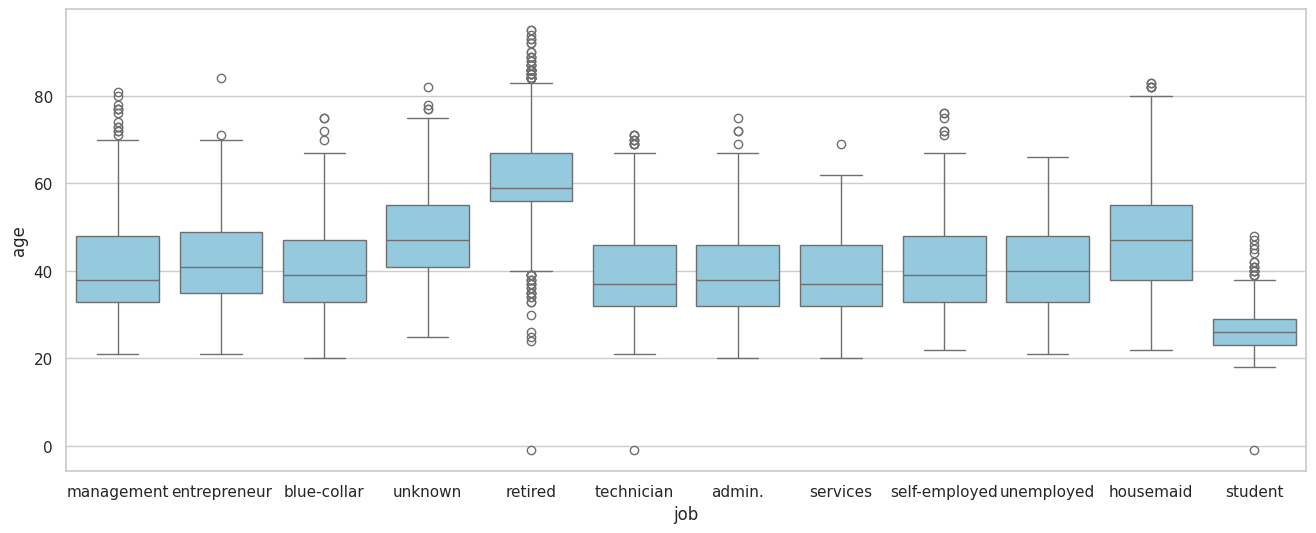

In [86]:
plt.figure(figsize=(16,6))
sns.boxplot(x=bdf['job'],y=bdf['age'], color='skyblue')
plt.axes
plt.show()

In [ ]:
plt.figure(figsize=(16,6))
sns.histplot()

In [102]:
bdf['job'].value_counts()
bdf.info()
var_num= bdf.select_dtypes(include=['float64', 'int64'])
var_num.drop(['Id'], axis=1)
var_num.corr()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         45211 non-null  int64  
 1   age        45199 non-null  float64
 2   job        45210 non-null  object 
 3   marital    45211 non-null  object 
 4   education  45211 non-null  object 
 5   default    45211 non-null  object 
 6   balance    45208 non-null  float64
 7   housing    45211 non-null  object 
 8   loan       45211 non-null  object 
 9   contact    45211 non-null  object 
 10  day        45211 non-null  int64  
 11  month      45211 non-null  object 
 12  duration   45211 non-null  int64  
 13  campaign   45211 non-null  int64  
 14  pdays      45211 non-null  int64  
 15  previous   45211 non-null  int64  
 16  poutcome   45211 non-null  object 
 17  y          45211 non-null  object 
dtypes: float64(2), int64(6), object(10)
memory usage: 6.2+ MB


,Id,age,balance,day,duration,campaign,pdays,previous
Id,1.000000,0.014502,0.073605,-0.061465,0.013031,-0.102884,0.437729,0.271098
age,0.014502,1.000000,0.097703,-0.009176,-0.004798,0.004880,-0.023715,0.000814
balance,0.073605,0.097703,1.000000,0.004471,0.021554,-0.014592,0.003425,0.016668
day,-0.061465,-0.009176,0.004471,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,0.013031,-0.004798,0.021554,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,-0.102884,0.004880,-0.014592,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,0.437729,-0.023715,0.003425,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.271098,0.000814,0.016668,-0.051710,0.001203,-0.032855,0.454820,1.000000


*MODELO LOGIT DE "SUJETO DE CRÉDITO Y DEFAULT" DE CLIENTES*

NameError: name 'mpl' is not defined

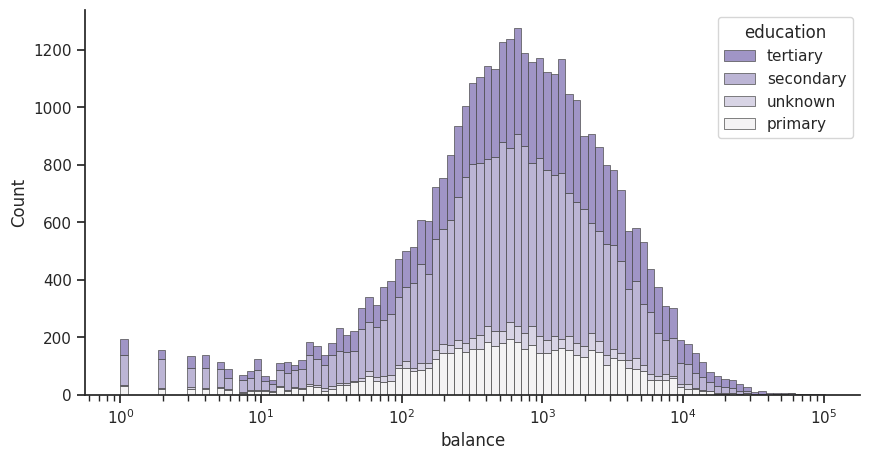

In [124]:
#Variables de interés:
#'poutcome'= Resultado de un prestamo
# loan = si es sujeto de crédito o no
# age, marital, job, education, housing = variables socio-demográficas de los sujetos
# var numericas:
#

import matplotlib.ticker as mpl_ticker # Importamos matplotlib.ticker con el alias mpl_ticker

bdf['default'].value_counts()
sns.set_theme(style="ticks")

f, ax = plt.subplots(figsize=(10, 5))
sns.despine(f)

sns.histplot(
    bdf,
    x="balance", hue="education",
    multiple="stack",
    palette="light:m_r",
    edgecolor=".3",
    linewidth=.5,
    log_scale=True,
)
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xticks(array_estadigrafos)

In [126]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [150]:
#vemos frecuencias de variables objetivo
print(bdf['marital'].value_counts())
print(bdf['loan'].value_counts())
print(bdf['poutcome'].value_counts())
print(bdf['default'].value_counts())

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
loan
no     37967
yes     7244
Name: count, dtype: int64
poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64
default
no     44396
yes      815
Name: count, dtype: int64


In [171]:
#Seleccionamos variables del modelo
lgvars= pd.DataFrame(bdf[['age', 'balance', 'marital', 'job', 'education', 'housing','loan','default']])
print(lgvars.nlargest)
lgvars = lgvars.dropna(subset=['age','balance'])
lgvars['loan'].replace({'yes':1,'no':0}, inplace=True)
lgvars['default'].replace({'yes':1,'no':0}, inplace=True)
print(lgvars.head(5))

<bound method DataFrame.nlargest of         age  balance   marital           job  education housing loan default
0       NaN   2143.0   married    management   tertiary     yes   no      no
1       NaN     29.0    single           NaN  secondary     yes   no      no
2       NaN      2.0   married  entrepreneur  secondary     yes  yes      no
3      47.0   1506.0   married   blue-collar    unknown     yes   no      no
4      33.0      1.0    single       unknown    unknown      no   no      no
...     ...      ...       ...           ...        ...     ...  ...     ...
45206  51.0    825.0   married    technician   tertiary      no   no      no
45207  71.0   1729.0  divorced       retired    primary      no   no      no
45208  72.0   5715.0   married       retired  secondary      no   no      no
45209  57.0    668.0   married   blue-collar  secondary      no   no      no
45210  37.0   2971.0   married  entrepreneur  secondary      no   no      no

[45211 rows x 8 columns]>
     age  bal

In [172]:
#creamos niveles para variables categóricas
lgvarsbool = pd.get_dummies(lgvars, columns=['marital', 'job', 'education', 'housing'], drop_first=True)
print(lgvarsbool.head(5))
X = np.asarray(lgvarsbool.drop(columns=['loan','default']))
X[0:5]  #print the first 5 values

     age  balance  loan  default  marital_married  marital_single  \
3   47.0   1506.0     0        0             True           False   
4   33.0      1.0     0        0            False            True   
5   35.0    231.0     0        0             True           False   
6   28.0    447.0     1        0            False            True   
10  41.0    270.0     0        0            False           False   

    job_blue-collar  job_entrepreneur  job_housemaid  job_management  ...  \
3              True             False          False           False  ...   
4             False             False          False           False  ...   
5             False             False          False            True  ...   
6             False             False          False            True  ...   
10            False             False          False           False  ...   

    job_self-employed  job_services  job_student  job_technician  \
3               False         False        False      

array([[47.0, 1506.0, True, False, True, False, False, False, False,
        False, False, False, False, False, False, False, False, True,
        True],
       [33.0, 1.0, False, True, False, False, False, False, False, False,
        False, False, False, False, True, False, False, True, False],
       [35.0, 231.0, True, False, False, False, False, True, False,
        False, False, False, False, False, False, False, True, False,
        True],
       [28.0, 447.0, False, True, False, False, False, True, False,
        False, False, False, False, False, False, False, True, False,
        True],
       [41.0, 270.0, False, False, False, False, False, False, False,
        False, False, False, False, False, False, True, False, False,
        True]], dtype=object)

In [194]:
#Definimos como array la variable objetivo
y = np.asarray(lgvars['default'])
y[0:5] #print the first 5 values

array([0, 0, 0, 0, 0])

In [195]:
#Standarizamos variables numericas para que el modelo aprenda más rápido
X_norm = StandardScaler().fit(X).transform(X)
X_norm[0:2]

array([[ 0.57110232,  0.04708898,  0.81312104, -0.62798617,  1.90921926,
        -0.18425176, -0.1679565 , -0.51436378, -0.22958399, -0.19026469,
        -0.31809448, -0.14557963, -0.44939067, -0.17229379, -0.08008101,
        -1.02684424, -0.64559232,  4.83373143,  0.89412445],
       [-0.74679792, -0.44714307, -1.22982919,  1.59239175, -0.52377431,
        -0.18425176, -0.1679565 , -0.51436378, -0.22958399, -0.19026469,
        -0.31809448, -0.14557963, -0.44939067, -0.17229379, 12.48735471,
        -1.02684424, -0.64559232,  4.83373143, -1.11841254]])

In [233]:
#Preparamos conjuntos de aprendizaje y prueba
X_train, X_test, y_train, y_test = train_test_split( X_norm, y, test_size=0.4, random_state=4)


In [234]:
#Creamos modelo logit
LR = LogisticRegression().fit(X_train,y_train)


In [235]:
yhat = LR.predict(X_test)
yhat[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [236]:
#observamos probabilidades de y sombrero
yhat_prob = LR.predict_proba(X_test)
y_pred = LR.predict(X_test)
yhat_prob[:10]

array([[9.99951039e-01, 4.89612757e-05],
       [1.00000000e+00, 2.36714398e-13],
       [9.79672733e-01, 2.03272671e-02],
       [9.73480447e-01, 2.65195533e-02],
       [9.84788067e-01, 1.52119335e-02],
       [9.91528981e-01, 8.47101886e-03],
       [9.70602540e-01, 2.93974599e-02],
       [9.60170462e-01, 3.98295384e-02],
       [9.66062773e-01, 3.39372267e-02],
       [9.83884272e-01, 1.61157282e-02]])

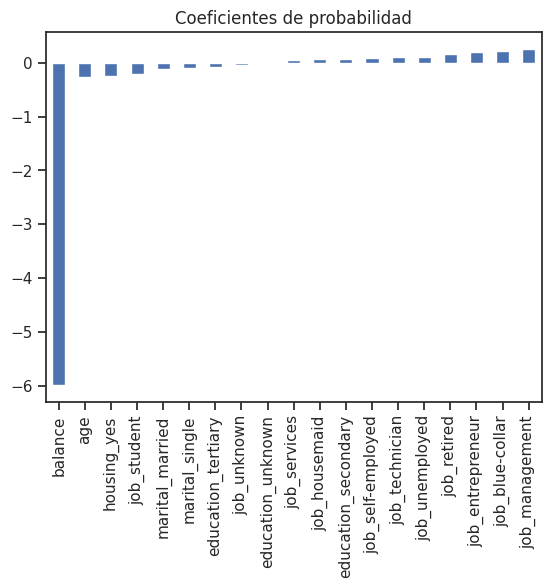

In [237]:
#observamos coeficientes de probabilidad para riesgo de crédito
caracts_modelo=lgvarsbool.drop(columns=['loan','default'])
coefficientes = pd.Series(LR.coef_[0], index=caracts_modelo.columns)
plt.title("Coeficientes de probabilidad")
coefficientes.sort_values().plot(kind='bar')
plt.show()


In [238]:
#calculamos coeficiente de pérdida logartimica para evaluar ajuste del modelo
log_loss(y_test, yhat_prob)

0.07387989295026925

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     17749
           1       0.86      0.02      0.04       330

    accuracy                           0.98     18079
   macro avg       0.92      0.51      0.51     18079
weighted avg       0.98      0.98      0.97     18079



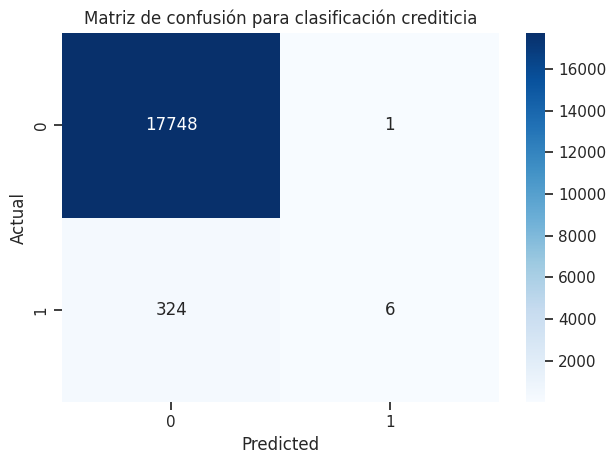

In [239]:
#Evaluación del primer modelo
print(classification_report(y_test, y_pred))

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

# Set the title and labels
plt.title('Matriz de confusión para clasificación crediticia')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

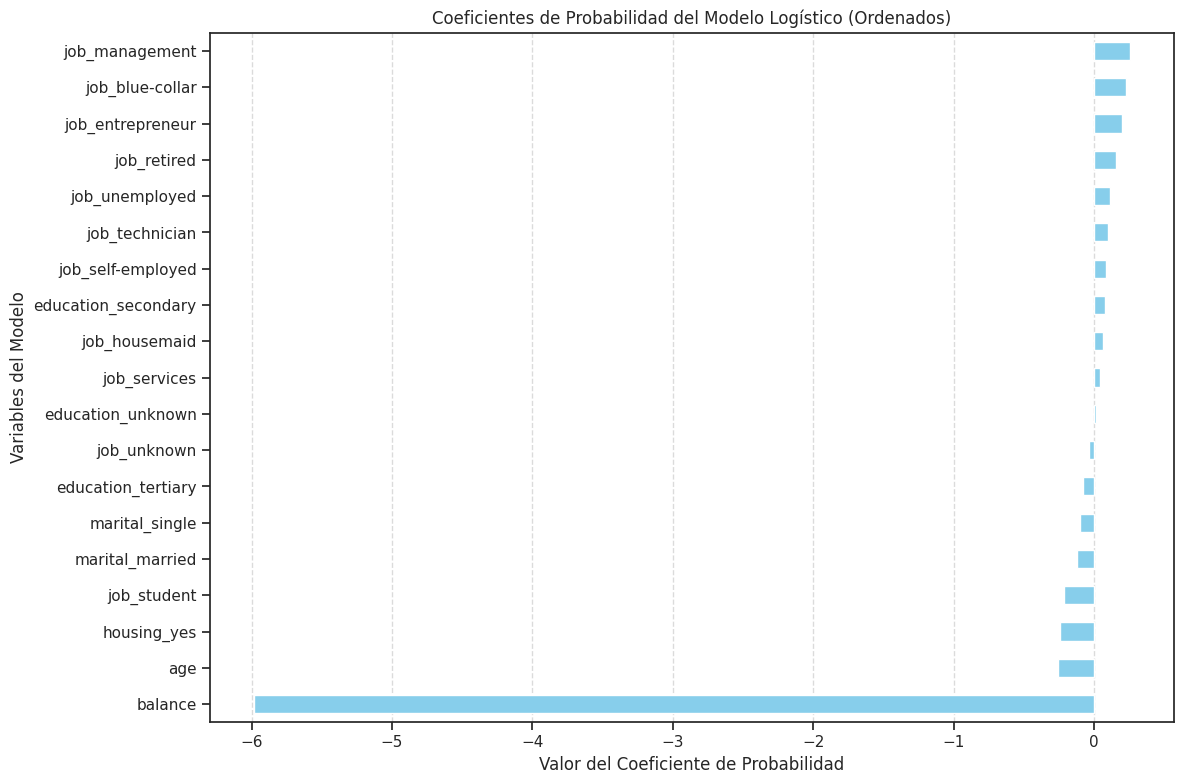

In [240]:
# Ordenamos los coeficientes para visualizar su impacto, de menor a mayor
coefficientes_ordenados = coefficientes.sort_values()

# Creamos el gráfico de barras horizontal
plt.figure(figsize=(12, 8)) # Ajustamos el tamaño para mejor visibilidad
coefficientes_ordenados.plot(kind='barh', color='skyblue')

plt.title('Coeficientes de Probabilidad del Modelo Logístico (Ordenados)')
plt.xlabel('Valor del Coeficiente de Probabilidad')
plt.ylabel('Variables del Modelo')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajusta el diseño para que no haya superposiciones
plt.show()

*Creamos modelo restringido para evaluar efecto del balance en cuenta corriente sobre la probabilidad de impago*

In [214]:
X2 = np.asarray(lgvarsbool.drop(columns=['loan','default','balance']))
X2[0:5]  #print the first 5 values
#Definimos como array la variable objetivo
y2 = np.asarray(lgvars['default'])
y2[0:5] #print the first 5 values
#Standarizamos variables numericas para que el modelo aprenda más rápido
X_norm2 = StandardScaler().fit(X2).transform(X2)
X_norm2[0:2]

array([[ 0.57110232,  0.81312104, -0.62798617,  1.90921926, -0.18425176,
        -0.1679565 , -0.51436378, -0.22958399, -0.19026469, -0.31809448,
        -0.14557963, -0.44939067, -0.17229379, -0.08008101, -1.02684424,
        -0.64559232,  4.83373143,  0.89412445],
       [-0.74679792, -1.22982919,  1.59239175, -0.52377431, -0.18425176,
        -0.1679565 , -0.51436378, -0.22958399, -0.19026469, -0.31809448,
        -0.14557963, -0.44939067, -0.17229379, 12.48735471, -1.02684424,
        -0.64559232,  4.83373143, -1.11841254]])

In [225]:
#Preparamos conjuntos de aprendizaje y prueba
X_train2, X_test2, y_train2, y_test2 = train_test_split( X_norm2, y2, test_size=0.4, random_state=4)


In [226]:
LR2 = LogisticRegression().fit(X_train2,y_train2)

In [227]:
yhat2 = LR2.predict(X_test2)
yhat2[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [228]:
yhat_prob2 = LR2.predict_proba(X_test2)
y_pred2 = LR2.predict(X_test2)
yhat_prob2[:10]

array([[0.98839427, 0.01160573],
       [0.98441328, 0.01558672],
       [0.98992708, 0.01007292],
       [0.98161353, 0.01838647],
       [0.97760571, 0.02239429],
       [0.98413803, 0.01586197],
       [0.98787171, 0.01212829],
       [0.97368431, 0.02631569],
       [0.97816105, 0.02183895],
       [0.97491718, 0.02508282]])

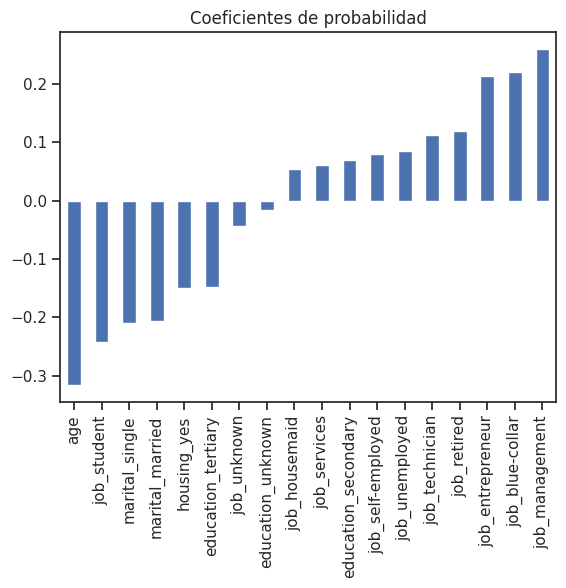

In [229]:
#observamos coeficientes de probabilidad para sujetos de crédito según el modelo restringido
caracts_modelo2=lgvarsbool.drop(columns=['loan','default', 'balance'])
coefficientes2 = pd.Series(LR2.coef_[0], index=caracts_modelo2.columns)
plt.title("Coeficientes de probabilidad")
coefficientes2.sort_values().plot(kind='bar')
plt.show()

In [230]:
#calculamos coeficiente de pérdida logartimica para evaluar ajuste del modelo
log_loss(y_test2, yhat_prob2)

0.09011692345969409

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     17749
           1       0.00      0.00      0.00       330

    accuracy                           0.98     18079
   macro avg       0.49      0.50      0.50     18079
weighted avg       0.96      0.98      0.97     18079



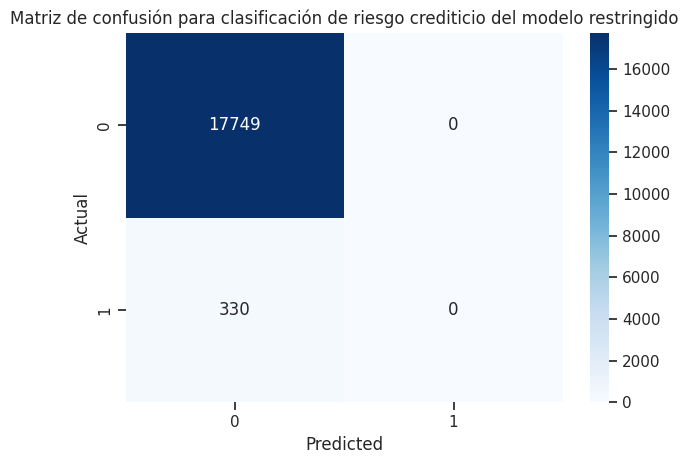

In [231]:
#Evaluación del segundo modelo
print(classification_report(y_test2, y_pred2))

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
conf_matrix2 = confusion_matrix(y_test2, y_pred2)

plt.figure()
sns.heatmap(conf_matrix2, annot=True, cmap='Blues', fmt='d')

# Set the title and labels
plt.title('Matriz de confusión para clasificación de riesgo crediticio del modelo restringido')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

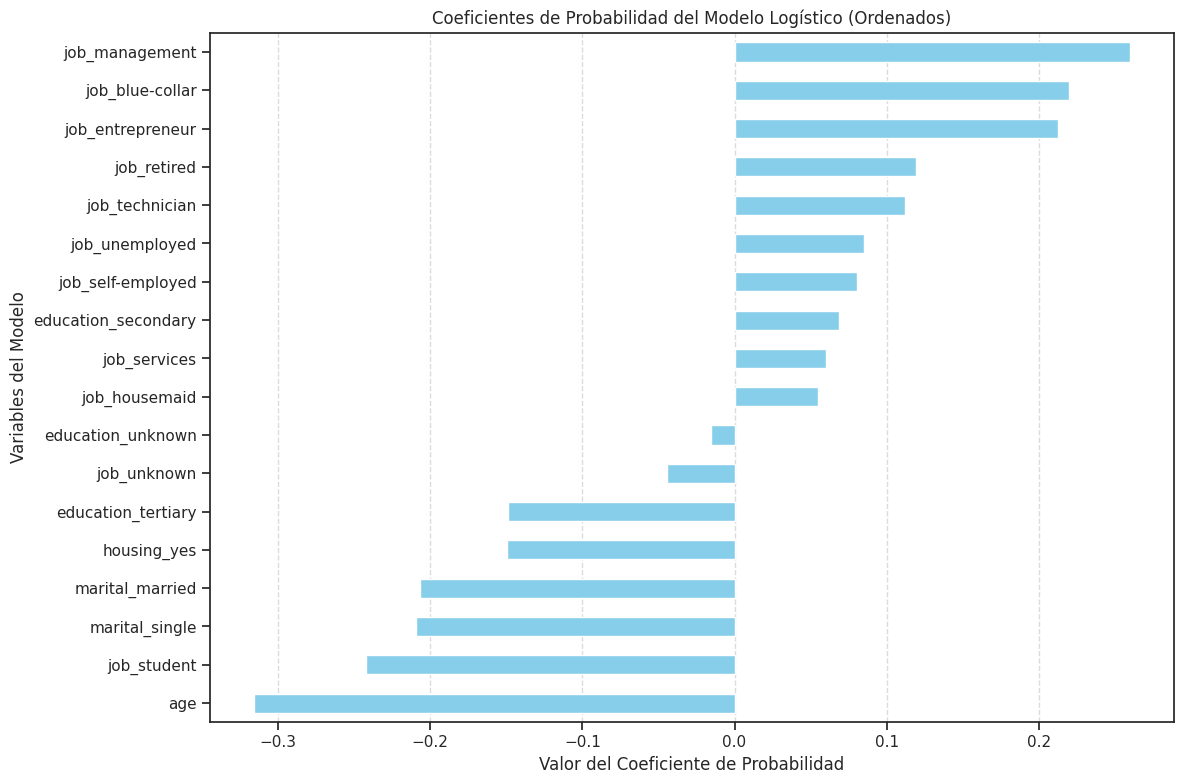

In [232]:
# Ordenamos los coeficientes para visualizar su impacto, de menor a mayor
coefficientes_ordenados2 = coefficientes2.sort_values()

# Creamos el gráfico de barras horizontal
plt.figure(figsize=(12, 8)) # Ajustamos el tamaño para mejor visibilidad
coefficientes_ordenados2.plot(kind='barh', color='skyblue')

plt.title('Coeficientes de Probabilidad del Modelo Logístico (Ordenados)')
plt.xlabel('Valor del Coeficiente de Probabilidad')
plt.ylabel('Variables del Modelo')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajusta el diseño para que no haya superposiciones
plt.show()

 *Conclusión*

---


Partiendo desde que desconozco la verdadera naturaleza del origen y función de los datos, intenté en mi poca experiencia de programa en python de hacer un modelo logit para probar la probabilidad de impago (default=1) según el registro de un banco con sus clientes. Ambos modelos parecen estar bien balanceados en el sentido de que tras cambiar la proporción de los conjunto de entrenamiento y prueba (test_size: 0.2 -> 0.4) la pérdida logaritmica presenta un incremento ínfimo, destacando como principal componente probabilístico las variables cualitativas y la edad.
Respecto a la variable cuantitativa de 'balance', se estima en el primer modelo un valor significativo para la estimación de la probabilidad por sobre el resto. Tras realizar un modelo restringido donde se excluye la variable observamos que tanto la tabla de puntuaciones, como matriz de confusión (y coeficiente de pérdida logaritmica) no demuestran variación significativa, por lo que su valor radicaba exclusivamente en su varianza inflada como coeficiente regresor. Con esta variable fuera encontramos que las demás parecen estar bien balanceadas como componentes de probabilidad de no pago, siendo el trabajo y la edad los principales decidores del evento en estudio, lo que podemos asociar con su nivel de ingresos directamente y el riesgo de liquidez que tienen asociados.

---


Este es un trabajo realizado desde entusiasmo por el mundo de los datos y la estadística. Como mi primer trabajo reconozco notables deficiencias a lo largo de la codificación, pero confío que a lo largo del tiempo podré plasmar de mejor manera mis ideas y lograr una expertise que pueda otorgar valor a los demás e incluso motivar a otros jóvenes que quieren aprender y no tienen ni buenos medios ni buenos maestros.
A quien sea que lea esta nota, le deseo un buen día y buena suerte, también mucho provecho en su tiempo de estudio.
M.V.

 origen de los datos: [texto del enlace](https://www.kaggle.com/datasets/ara001/bank-client-attributes-and-marketing-outcomes)